# Hail V1 - MRMS Full-Grid M0 Daily Evidence Batch

**Peril:** hail - **Layer:** M0 daily cell evidence - **Product:** `hazard_conus_grid` V1

This notebook is the next step after the full MRMS source inventory:

```text
accepted MRMS source dates
  -> read selected daily MESH tiles
  -> aggregate native pixels to every served CONUS benchmark cell
  -> write one row per cell_id x date
  -> save daily CONUS QA maps, batch summaries, and metadata
```

It deliberately does **not** compute annual frequency, build M1, choose Cloud Run/Batch, de-bias MESH, fit
tails, use MYRORSS, or run risk metrics.

Plan references:

- `docs/plans/hazard_conus_grid/hail/m0_m1_scaleout_execution.md`
- `docs/plans/hazard_conus_grid/hail/v1_mrms_only_grid_build.md`
- `docs/plans/hazard_conus_grid/decisions.md` / DD-G7

## 0 - Scope and controls

Default execution is the seven-day window already used for source-inventory proof and one-day map QA:
`2024-06-01` through `2024-06-07`.

Override with environment variables:

```bash
MRMS_M0_BATCH_START=YYYY-MM-DD
MRMS_M0_BATCH_END=YYYY-MM-DD
MRMS_SOURCE_INVENTORY_RUN_ID=20260616T165806Z
HAZARD_CONUS_GRID_UPLOAD_TO_GCS=1
HAZARD_CONUS_GRID_RUN_ID=YYYYMMDDTHHMMSSZ
```

The source inventory defines what dates are allowed. This notebook refuses to process dates that are not
marked `accepted_for_v1 = true`.

In [1]:
from __future__ import annotations

import gzip
import json
import os
import re
import subprocess
import tempfile
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xarray as xr
from IPython.display import Image, display

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 120})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "common" / "benchmark_grid"
HAIL_GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "hail"
MRMS_CACHE = ROOT / "data" / "hail" / "mrms_raw"

THRESHOLD_MM = 25.4
PRODUCT = "CONUS/MESH_Max_1440min_00.50"
SOURCE_INVENTORY_RUN_ID = os.environ.get("MRMS_SOURCE_INVENTORY_RUN_ID", "20260616T165806Z")
BATCH_START_DATE = os.environ.get("MRMS_M0_BATCH_START", "2024-06-01")
BATCH_END_DATE = os.environ.get("MRMS_M0_BATCH_END", "2024-06-07")
BATCH_LABEL = (
    f"{pd.Timestamp(BATCH_START_DATE).strftime('%Y%m%d')}_"
    f"{pd.Timestamp(BATCH_END_DATE).strftime('%Y%m%d')}"
)
RUN_ID = os.environ.get(
    "HAZARD_CONUS_GRID_RUN_ID",
    datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ"),
)
UPLOAD_TO_GCS = os.environ.get("HAZARD_CONUS_GRID_UPLOAD_TO_GCS", "0").lower() in {
    "1",
    "true",
    "yes",
}

SOURCE_INVENTORY_DIR = (
    HAIL_GRID_DIR / "v1_mrms_only" / "m0_source_inventory" / f"run_id={SOURCE_INVENTORY_RUN_ID}"
)
INVENTORY_PARQUET_CANDIDATES = sorted(SOURCE_INVENTORY_DIR.glob("mrms_v1_source_inventory_*.parquet"))
if not INVENTORY_PARQUET_CANDIDATES:
    raise FileNotFoundError(f"no source inventory parquet found under {SOURCE_INVENTORY_DIR}")
SOURCE_INVENTORY_PARQUET = INVENTORY_PARQUET_CANDIDATES[0]

LOCAL_RUN_DIR = (
    HAIL_GRID_DIR
    / "v1_mrms_only"
    / "m0_daily_cell_evidence"
    / f"run_id={RUN_ID}"
    / f"batch={BATCH_LABEL}"
)
QA_MAP_DIR = LOCAL_RUN_DIR / "qa" / "maps"
COMBINED_PANEL_PARQUET = LOCAL_RUN_DIR / f"mrms_v1_m0_daily_cell_evidence_{BATCH_LABEL}_{RUN_ID}.parquet"
BATCH_MANIFEST_CSV = LOCAL_RUN_DIR / f"mrms_v1_m0_batch_manifest_{BATCH_LABEL}_{RUN_ID}.csv"
DAILY_STATUS_SUMMARY_CSV = LOCAL_RUN_DIR / f"mrms_v1_m0_daily_status_summary_{BATCH_LABEL}_{RUN_ID}.csv"
TOP_CELLS_CSV = LOCAL_RUN_DIR / f"mrms_v1_m0_top_cells_{BATCH_LABEL}_{RUN_ID}.csv"
METADATA_JSON = LOCAL_RUN_DIR / f"metadata_{BATCH_LABEL}_{RUN_ID}.json"
GCS_RUN_ROOT = (
    "gs://infrasure-benchmark/"
    f"hazard_conus_grid/dev/hail/v1_mrms_only/m0_daily_cell_evidence/run_id={RUN_ID}/batch={BATCH_LABEL}"
)

print("repo root:", ROOT)
print("batch window:", BATCH_START_DATE, "to", BATCH_END_DATE)
print("run_id:", RUN_ID)
print("source inventory:", SOURCE_INVENTORY_PARQUET.relative_to(ROOT))
print("local run dir:", LOCAL_RUN_DIR.relative_to(ROOT))
print("gcs run root:", GCS_RUN_ROOT)
print("upload_to_gcs:", UPLOAD_TO_GCS)

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
batch window: 2024-06-01 to 2024-06-07
run_id: 20260616T172929Z
source inventory: data/hazard_conus_grid/hail/v1_mrms_only/m0_source_inventory/run_id=20260616T165806Z/mrms_v1_source_inventory_20140101_20260615_20260616T165806Z.parquet
local run dir: data/hazard_conus_grid/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607
gcs run root: gs://infrasure-benchmark/hazard_conus_grid/dev/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607
upload_to_gcs: False


## 1 - Benchmark grid and accepted source dates

The expected output row count is:

```text
n_accepted_batch_dates x 13,085 served CONUS cells
```

Missing source dates are not zeros. They are excluded unless the source inventory explicitly accepts them.

In [2]:
served = pd.read_csv(GRID_DIR / "served_conus_cell_ids_v2026_06.csv")
served["cell_id"] = served["cell_id"].astype("int64")

required_grid_columns = ["cell_id", "lat_idx", "lon_idx", "lat_center", "lon_center", "state_abbr", "iso_rto"]
missing_grid_columns = sorted(set(required_grid_columns) - set(served.columns))
if missing_grid_columns:
    raise ValueError(f"served mask missing columns: {missing_grid_columns}")
if not served["cell_id"].is_unique:
    raise ValueError("served mask cell_id is not unique")

served = served[required_grid_columns].copy()
served_cell_ids = set(served["cell_id"])

inventory = pd.read_parquet(SOURCE_INVENTORY_PARQUET)
inventory["date"] = pd.to_datetime(inventory["date"]).dt.date.astype(str)
batch_dates = pd.date_range(BATCH_START_DATE, BATCH_END_DATE, freq="D").strftime("%Y-%m-%d").tolist()

batch_inventory = inventory[inventory["date"].isin(batch_dates)].copy().sort_values("date")
missing_dates = sorted(set(batch_dates) - set(batch_inventory["date"]))
not_accepted = batch_inventory.loc[~batch_inventory["accepted_for_v1"], ["date", "list_status", "skip_or_failure_reason"]]

if missing_dates:
    raise ValueError(f"batch dates missing from source inventory: {missing_dates}")
if not not_accepted.empty:
    raise ValueError(f"batch contains dates not accepted for V1:\n{not_accepted.to_string(index=False)}")
if len(batch_inventory) != len(batch_dates):
    raise AssertionError("batch inventory row count does not match requested date count")

grid_batch_summary = pd.DataFrame(
    [
        ("served_cells", len(served), "cells", "daily row denominator"),
        ("batch_dates", len(batch_inventory), "dates", "accepted source days in this run"),
        ("expected_panel_rows", len(served) * len(batch_inventory), "rows", "cell_id x date"),
        ("source_inventory_run_id", SOURCE_INVENTORY_RUN_ID, "run", "accepted-date denominator"),
    ],
    columns=["item", "value", "unit/base", "why it matters"],
)
display(grid_batch_summary)
display(batch_inventory[["date", "selected_source_key", "selected_source_timestamp_utc", "selected_size_bytes"]])

,item,value,unit/base,why it matters
0,served_cells,13085,cells,daily row denominator
1,batch_dates,7,dates,accepted source days in this run
2,expected_panel_rows,91595,rows,cell_id x date
3,source_inventory_run_id,20260616T165806Z,run,accepted-date denominator


,date,selected_source_key,selected_source_timestamp_utc,selected_size_bytes
3804,2024-06-01,CONUS/MESH_Max_1440min_00.50/20240601/MRMS_MES...,2024-06-01T23:30:00+00:00,716118.0
3805,2024-06-02,CONUS/MESH_Max_1440min_00.50/20240602/MRMS_MES...,2024-06-02T23:30:00+00:00,958231.0
3806,2024-06-03,CONUS/MESH_Max_1440min_00.50/20240603/MRMS_MES...,2024-06-03T23:30:00+00:00,1119327.0
3807,2024-06-04,CONUS/MESH_Max_1440min_00.50/20240604/MRMS_MES...,2024-06-04T23:30:00+00:00,1069996.0
3808,2024-06-05,CONUS/MESH_Max_1440min_00.50/20240605/MRMS_MES...,2024-06-05T23:30:00+00:00,1300879.0
3809,2024-06-06,CONUS/MESH_Max_1440min_00.50/20240606/MRMS_MES...,2024-06-06T23:30:00+00:00,608899.0
3810,2024-06-07,CONUS/MESH_Max_1440min_00.50/20240607/MRMS_MES...,2024-06-07T23:30:00+00:00,806836.0


**Takeaway.** This batch is small enough for local verification but uses the same accepted inventory contract
that the scaled run must use.

## 2 - Source reader and aggregation helpers

In [3]:
def source_timestamp_from_name(path_or_key: str) -> pd.Timestamp:
    match = re.search(r"_(\d{8})-(\d{6})\.grib2\.gz$", Path(path_or_key).name)
    if not match:
        raise ValueError(f"cannot parse MRMS timestamp from {path_or_key}")
    return pd.to_datetime(f"{match.group(1)}{match.group(2)}", format="%Y%m%d%H%M%S", utc=True)


def fetch_inventory_source(row: pd.Series) -> Path:
    key = str(row["selected_source_key"])
    uri = str(row["selected_source_uri_https"])
    local = MRMS_CACHE / Path(key).name
    MRMS_CACHE.mkdir(parents=True, exist_ok=True)
    if local.exists() and local.stat().st_size > 0:
        return local

    response = requests.get(uri, timeout=180)
    response.raise_for_status()
    local.write_bytes(response.content)
    return local


def read_mrms_grib(gz_path: Path) -> xr.DataArray:
    raw = gzip.decompress(gz_path.read_bytes())
    with tempfile.NamedTemporaryFile(suffix=".grib2", delete=False) as tf:
        tf.write(raw)
        tmp = tf.name
    try:
        ds = xr.open_dataset(tmp, engine="cfgrib", backend_kwargs={"indexpath": ""})
        ds.load()
        da = ds[list(ds.data_vars)[0]].copy()
        ds.close()
        return da
    finally:
        os.unlink(tmp)


def native_points_to_cell_id(lat: np.ndarray, lon360: np.ndarray) -> np.ndarray:
    lat_idx = np.rint((90.0 - lat) / 0.25).astype("int64")
    lon_idx = (np.rint(lon360 / 0.25).astype("int64") % 1440)
    return lat_idx * 1440 + lon_idx


def native_observed_counts_for_served_cells(mrms_da: xr.DataArray, served_mask: pd.DataFrame) -> pd.DataFrame:
    lat_native_idx = np.rint((90.0 - mrms_da.latitude.values) / 0.25).astype("int64")
    lon_native_idx = (np.rint(mrms_da.longitude.values / 0.25).astype("int64") % 1440)
    lat_counts = pd.Series(lat_native_idx).value_counts().rename("n_native_rows")
    lon_counts = pd.Series(lon_native_idx).value_counts().rename("n_native_cols")

    counts = served_mask[["cell_id", "lat_idx", "lon_idx"]].copy()
    counts["n_native_rows"] = counts["lat_idx"].map(lat_counts).fillna(0).astype("int64")
    counts["n_native_cols"] = counts["lon_idx"].map(lon_counts).fillna(0).astype("int64")
    counts["n_native_pixels_observed"] = counts["n_native_rows"] * counts["n_native_cols"]
    return counts[["cell_id", "n_native_pixels_observed"]]


def aggregate_pixels_to_cells(
    mrms_da: xr.DataArray,
    values: np.ndarray,
    mask: np.ndarray,
    value_name: str,
) -> pd.DataFrame:
    y, x = np.where(mask)
    if len(y) == 0:
        return pd.DataFrame(columns=["cell_id"])

    cell_ids = native_points_to_cell_id(mrms_da.latitude.values[y], mrms_da.longitude.values[x])
    pixel_df = pd.DataFrame({"cell_id": cell_ids, value_name: values[y, x]})
    pixel_df = pixel_df[pixel_df["cell_id"].isin(served_cell_ids)]
    return pixel_df


def build_daily_panel(row: pd.Series) -> tuple[pd.DataFrame, dict[str, Any]]:
    date_str = str(row["date"])
    t0 = time.perf_counter()
    source_path = fetch_inventory_source(row)
    da = read_mrms_grib(source_path)
    arr = da.values.astype("float32")
    source_timestamp = source_timestamp_from_name(source_path.name)

    observed_counts = native_observed_counts_for_served_cells(da, served)
    positive_pixels = aggregate_pixels_to_cells(da, arr, arr > 0, "mesh_mm")
    severe_pixels = aggregate_pixels_to_cells(da, arr, arr >= THRESHOLD_MM, "mesh_mm")

    positive_agg = (
        positive_pixels.groupby("cell_id")["mesh_mm"]
        .agg(
            n_native_pixels_positive="size",
            mesh_max_mm="max",
            mesh_mean_positive_mm="mean",
        )
        .reset_index()
        if not positive_pixels.empty
        else pd.DataFrame(columns=["cell_id", "n_native_pixels_positive", "mesh_max_mm", "mesh_mean_positive_mm"])
    )

    severe_agg = (
        severe_pixels.groupby("cell_id")["mesh_mm"]
        .agg(
            n_native_pixels_severe="size",
            mesh_mean_severe_mm="mean",
            mesh_p50_severe_mm=lambda s: s.quantile(0.50),
            mesh_p90_severe_mm=lambda s: s.quantile(0.90),
            mesh_p95_severe_mm=lambda s: s.quantile(0.95),
        )
        .reset_index()
        if not severe_pixels.empty
        else pd.DataFrame(
            columns=[
                "cell_id",
                "n_native_pixels_severe",
                "mesh_mean_severe_mm",
                "mesh_p50_severe_mm",
                "mesh_p90_severe_mm",
                "mesh_p95_severe_mm",
            ]
        )
    )

    panel = (
        served.merge(observed_counts, on="cell_id", how="left")
        .merge(positive_agg, on="cell_id", how="left")
        .merge(severe_agg, on="cell_id", how="left")
    )

    for col in ["n_native_pixels_observed", "n_native_pixels_positive", "n_native_pixels_severe"]:
        panel[col] = panel[col].fillna(0).astype("int64")

    panel["hazard"] = "hail"
    panel["date"] = pd.Timestamp(date_str)
    panel["source_product"] = PRODUCT
    panel["source_key"] = row["selected_source_key"]
    panel["source_uri_https"] = row["selected_source_uri_https"]
    panel["source_timestamp"] = source_timestamp
    panel["threshold_mm"] = THRESHOLD_MM
    panel["severe_area_km2_approx"] = panel["n_native_pixels_severe"].astype(float)
    panel["hail_day_flag"] = panel["n_native_pixels_severe"] > 0

    panel["coverage_status"] = np.select(
        [
            panel["n_native_pixels_observed"] == 0,
            panel["n_native_pixels_severe"] > 0,
            panel["n_native_pixels_positive"] > 0,
        ],
        [
            "no_native_pixel_coverage",
            "observed_severe_hail",
            "observed_sub_severe_hail",
        ],
        default="observed_no_hail",
    )

    panel["qa_flags"] = np.where(
        panel["coverage_status"] == "no_native_pixel_coverage",
        "no_native_pixel_coverage",
        "raw_mrms_mesh;negative_values_masked;v1_m0_batch",
    )

    ordered_columns = [
        "hazard",
        "cell_id",
        "date",
        "source_product",
        "source_key",
        "source_uri_https",
        "source_timestamp",
        "threshold_mm",
        "lat_center",
        "lon_center",
        "state_abbr",
        "iso_rto",
        "n_native_pixels_observed",
        "n_native_pixels_positive",
        "n_native_pixels_severe",
        "severe_area_km2_approx",
        "mesh_max_mm",
        "mesh_mean_positive_mm",
        "mesh_mean_severe_mm",
        "mesh_p50_severe_mm",
        "mesh_p90_severe_mm",
        "mesh_p95_severe_mm",
        "hail_day_flag",
        "coverage_status",
        "qa_flags",
    ]
    panel = panel[ordered_columns].sort_values("cell_id").reset_index(drop=True)

    if len(panel) != len(served):
        raise AssertionError(f"{date_str}: expected {len(served)} rows, got {len(panel)}")
    if not panel["cell_id"].is_unique:
        raise AssertionError(f"{date_str}: duplicate cell_id rows")

    stats = {
        "date": date_str,
        "source_path": str(source_path.relative_to(ROOT)),
        "source_key": row["selected_source_key"],
        "source_timestamp": source_timestamp.isoformat(),
        "source_size_bytes": int(source_path.stat().st_size),
        "read_status": "ok",
        "native_grid_shape": f"{da.shape[0]}x{da.shape[1]}",
        "native_positive_pixel_count": int((arr > 0).sum()),
        "native_severe_pixel_count": int((arr >= THRESHOLD_MM).sum()),
        "served_positive_pixel_count": int(panel["n_native_pixels_positive"].sum()),
        "served_severe_pixel_count": int(panel["n_native_pixels_severe"].sum()),
        "served_severe_cell_count": int((panel["coverage_status"] == "observed_severe_hail").sum()),
        "served_sub_severe_cell_count": int((panel["coverage_status"] == "observed_sub_severe_hail").sum()),
        "served_no_hail_cell_count": int((panel["coverage_status"] == "observed_no_hail").sum()),
        "served_no_coverage_cell_count": int((panel["coverage_status"] == "no_native_pixel_coverage").sum()),
        "max_mesh_mm": None if pd.isna(panel["mesh_max_mm"].max()) else float(panel["mesh_max_mm"].max()),
        "elapsed_seconds": round(time.perf_counter() - t0, 3),
    }
    return panel, stats


status_colors = {
    "observed_no_hail": "#d0d0d0",
    "observed_sub_severe_hail": "#fdae61",
    "observed_severe_hail": "#d7191c",
    "no_native_pixel_coverage": "#2b2b2b",
}


def write_status_map(panel: pd.DataFrame, date_str: str) -> Path:
    QA_MAP_DIR.mkdir(parents=True, exist_ok=True)
    png_path = QA_MAP_DIR / f"mrms_v1_m0_status_map_{date_str.replace('-', '')}_{RUN_ID}.png"
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for status, group in panel.groupby("coverage_status"):
        ax.scatter(
            group["lon_center"],
            group["lat_center"],
            s=7 if status != "observed_severe_hail" else 16,
            c=status_colors.get(status, "#888888"),
            label=f"{status} ({len(group):,})",
            alpha=0.8,
            linewidths=0,
        )
    ax.set_title(f"MRMS V1 M0 status by served CONUS cell - {date_str}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(loc="lower left", fontsize=8, frameon=True)
    fig.tight_layout()
    fig.savefig(png_path, bbox_inches="tight")
    plt.close(fig)
    return png_path

## 3 - Build the daily evidence panels

This cell is the actual batch proof. It writes per-date partitions plus an in-memory combined panel used for
QA summaries.

In [4]:
LOCAL_RUN_DIR.mkdir(parents=True, exist_ok=True)
QA_MAP_DIR.mkdir(parents=True, exist_ok=True)

daily_panels: list[pd.DataFrame] = []
manifest_rows: list[dict[str, Any]] = []
map_paths: list[Path] = []

batch_start_time = time.perf_counter()
for idx, (_, inv_row) in enumerate(batch_inventory.iterrows(), start=1):
    date_str = str(inv_row["date"])
    print(f"[{idx}/{len(batch_inventory)}] processing {date_str}", flush=True)
    day_panel, stats = build_daily_panel(inv_row)

    date_partition_dir = LOCAL_RUN_DIR / f"date={date_str}"
    date_partition_dir.mkdir(parents=True, exist_ok=True)
    date_partition_path = date_partition_dir / "part-000.parquet"
    day_panel.to_parquet(date_partition_path, index=False)

    map_path = write_status_map(day_panel, date_str)
    stats["partition_path"] = str(date_partition_path.relative_to(ROOT))
    stats["status_map_path"] = str(map_path.relative_to(ROOT))
    manifest_rows.append(stats)
    daily_panels.append(day_panel)
    map_paths.append(map_path)

batch_panel = pd.concat(daily_panels, ignore_index=True)
batch_manifest = pd.DataFrame(manifest_rows)

expected_rows = len(served) * len(batch_inventory)
if len(batch_panel) != expected_rows:
    raise AssertionError(f"expected {expected_rows} rows, got {len(batch_panel)}")
if batch_panel.duplicated(["cell_id", "date"]).any():
    raise AssertionError("batch panel has duplicate cell_id/date rows")

display(batch_manifest)
display(batch_panel.head())
display(batch_panel["coverage_status"].value_counts().rename_axis("coverage_status").reset_index(name="n_rows"))

[1/7] processing 2024-06-01


[2/7] processing 2024-06-02


[3/7] processing 2024-06-03


[4/7] processing 2024-06-04


[5/7] processing 2024-06-05


[6/7] processing 2024-06-06


[7/7] processing 2024-06-07


,date,source_path,source_key,source_timestamp,source_size_bytes,read_status,native_grid_shape,native_positive_pixel_count,native_severe_pixel_count,served_positive_pixel_count,served_severe_pixel_count,served_severe_cell_count,served_sub_severe_cell_count,served_no_hail_cell_count,served_no_coverage_cell_count,max_mesh_mm,elapsed_seconds,partition_path,status_map_path
0,2024-06-01,data/hail/mrms_raw/MRMS_MESH_Max_1440min_00.50...,CONUS/MESH_Max_1440min_00.50/20240601/MRMS_MES...,2024-06-01T23:30:00+00:00,716118,ok,3500x7000,438023,14773,327953,12529,292,1991,10802,0,95.500000,3.891,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...
1,2024-06-02,data/hail/mrms_raw/MRMS_MESH_Max_1440min_00.50...,CONUS/MESH_Max_1440min_00.50/20240602/MRMS_MES...,2024-06-02T23:30:00+00:00,958231,ok,3500x7000,617557,23310,516287,16805,367,2788,9930,0,103.199997,0.530,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...
2,2024-06-03,data/hail/mrms_raw/MRMS_MESH_Max_1440min_00.50...,CONUS/MESH_Max_1440min_00.50/20240603/MRMS_MES...,2024-06-03T23:30:00+00:00,1119327,ok,3500x7000,740231,9686,679255,8165,282,3723,9080,0,96.300003,0.478,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...
3,2024-06-04,data/hail/mrms_raw/MRMS_MESH_Max_1440min_00.50...,CONUS/MESH_Max_1440min_00.50/20240604/MRMS_MES...,2024-06-04T23:30:00+00:00,1069996,ok,3500x7000,633875,6838,536105,5001,182,3659,9244,0,207.800003,0.443,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...
4,2024-06-05,data/hail/mrms_raw/MRMS_MESH_Max_1440min_00.50...,CONUS/MESH_Max_1440min_00.50/20240605/MRMS_MES...,2024-06-05T23:30:00+00:00,1300879,ok,3500x7000,772988,5195,569297,3829,125,4244,8716,0,83.699997,0.461,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...
5,2024-06-06,data/hail/mrms_raw/MRMS_MESH_Max_1440min_00.50...,CONUS/MESH_Max_1440min_00.50/20240606/MRMS_MES...,2024-06-06T23:30:00+00:00,608899,ok,3500x7000,287324,4452,162868,1309,65,2329,10691,0,110.800003,0.465,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...
6,2024-06-07,data/hail/mrms_raw/MRMS_MESH_Max_1440min_00.50...,CONUS/MESH_Max_1440min_00.50/20240607/MRMS_MES...,2024-06-07T23:30:00+00:00,806836,ok,3500x7000,446216,8815,220702,6014,137,2400,10548,0,74.800003,0.429,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...,data/hazard_conus_grid/hail/v1_mrms_only/m0_da...


,hazard,cell_id,date,source_product,source_key,source_uri_https,source_timestamp,threshold_mm,lat_center,lon_center,...,severe_area_km2_approx,mesh_max_mm,mesh_mean_positive_mm,mesh_mean_severe_mm,mesh_p50_severe_mm,mesh_p90_severe_mm,mesh_p95_severe_mm,hail_day_flag,coverage_status,qa_flags
0,hail,235780,2024-06-01,CONUS/MESH_Max_1440min_00.50,CONUS/MESH_Max_1440min_00.50/20240601/MRMS_MES...,https://noaa-mrms-pds.s3.amazonaws.com/CONUS/M...,2024-06-01 23:30:00+00:00,25.4,49.25,-95.00,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,False,observed_no_hail,raw_mrms_mesh;negative_values_masked;v1_m0_batch
1,hail,237109,2024-06-01,CONUS/MESH_Max_1440min_00.50,CONUS/MESH_Max_1440min_00.50/20240601/MRMS_MES...,https://noaa-mrms-pds.s3.amazonaws.com/CONUS/M...,2024-06-01 23:30:00+00:00,25.4,49.00,-122.75,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,False,observed_no_hail,raw_mrms_mesh;negative_values_masked;v1_m0_batch
2,hail,237110,2024-06-01,CONUS/MESH_Max_1440min_00.50,CONUS/MESH_Max_1440min_00.50/20240601/MRMS_MES...,https://noaa-mrms-pds.s3.amazonaws.com/CONUS/M...,2024-06-01 23:30:00+00:00,25.4,49.00,-122.50,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,False,observed_no_hail,raw_mrms_mesh;negative_values_masked;v1_m0_batch
3,hail,237111,2024-06-01,CONUS/MESH_Max_1440min_00.50,CONUS/MESH_Max_1440min_00.50/20240601/MRMS_MES...,https://noaa-mrms-pds.s3.amazonaws.com/CONUS/M...,2024-06-01 23:30:00+00:00,25.4,49.00,-122.25,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,False,observed_no_hail,raw_mrms_mesh;negative_values_masked;v1_m0_batch
4,hail,237112,2024-06-01,CONUS/MESH_Max_1440min_00.50,CONUS/MESH_Max_1440min_00.50/20240601/MRMS_MES...,https://noaa-mrms-pds.s3.amazonaws.com/CONUS/M...,2024-06-01 23:30:00+00:00,25.4,49.00,-122.00,...,0.0,2.0,2.0,NaN,NaN,NaN,NaN,False,observed_sub_severe_hail,raw_mrms_mesh;negative_values_masked;v1_m0_batch


,coverage_status,n_rows
0,observed_no_hail,69011
1,observed_sub_severe_hail,21134
2,observed_severe_hail,1450


**Takeaway.** The batch output is now a real M0 daily evidence panel: one row per served CONUS cell per
accepted MRMS date, with no-hail, sub-severe, severe, and no-coverage states separated.

## 4 - QA summaries and CONUS map gallery

,date,coverage_status,n_cells,n_positive_pixels,n_severe_pixels,max_mesh_mm
0,2024-06-01,observed_no_hail,10802,0,0,NaN
1,2024-06-01,observed_severe_hail,292,114165,12529,95.500000
2,2024-06-01,observed_sub_severe_hail,1991,213788,0,25.200001
3,2024-06-02,observed_no_hail,9930,0,0,NaN
4,2024-06-02,observed_severe_hail,367,161920,16805,103.199997
5,2024-06-02,observed_sub_severe_hail,2788,354367,0,25.299999
6,2024-06-03,observed_no_hail,9080,0,0,NaN
7,2024-06-03,observed_severe_hail,282,128947,8165,96.300003
8,2024-06-03,observed_sub_severe_hail,3723,550308,0,25.299999
9,2024-06-04,observed_no_hail,9244,0,0,NaN


,date,cell_id,state_abbr,lat_center,lon_center,n_native_pixels_severe,mesh_max_mm
12338,2024-06-01,342306,TX,30.75,-103.50,385,74.099998
11106,2024-06-01,327907,NM,33.25,-103.25,326,63.599998
10634,2024-06-01,323586,NM,34.00,-103.50,320,71.000000
10796,2024-06-01,325026,NM,33.75,-103.50,278,56.200001
11551,2024-06-01,332228,TX,32.50,-103.00,248,61.400002
11687,2024-06-01,333669,TX,32.25,-102.75,236,56.700001
12337,2024-06-01,342305,TX,30.75,-103.75,227,72.099998
12143,2024-06-01,339423,TX,31.25,-104.25,214,51.200001
11105,2024-06-01,327906,NM,33.25,-103.50,212,51.500000
11714,2024-06-01,333696,TX,32.25,-96.00,208,85.900002


data/hazard_conus_grid/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607/qa/maps/mrms_v1_m0_status_map_20240601_20260616T172929Z.png


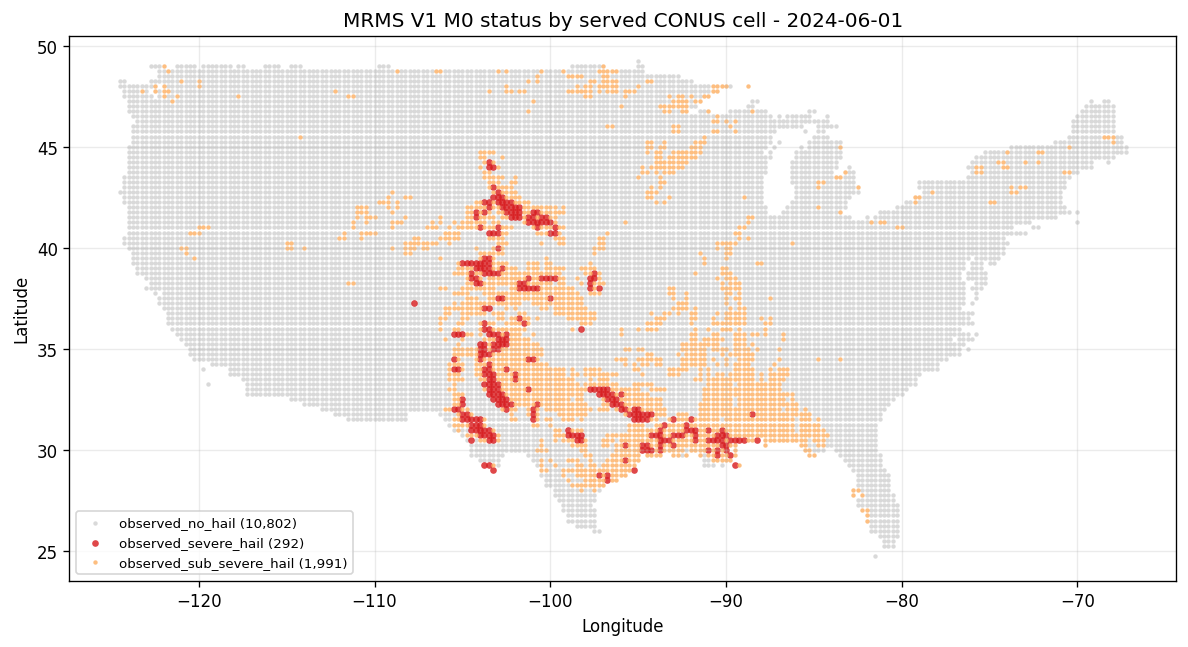

data/hazard_conus_grid/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607/qa/maps/mrms_v1_m0_status_map_20240602_20260616T172929Z.png


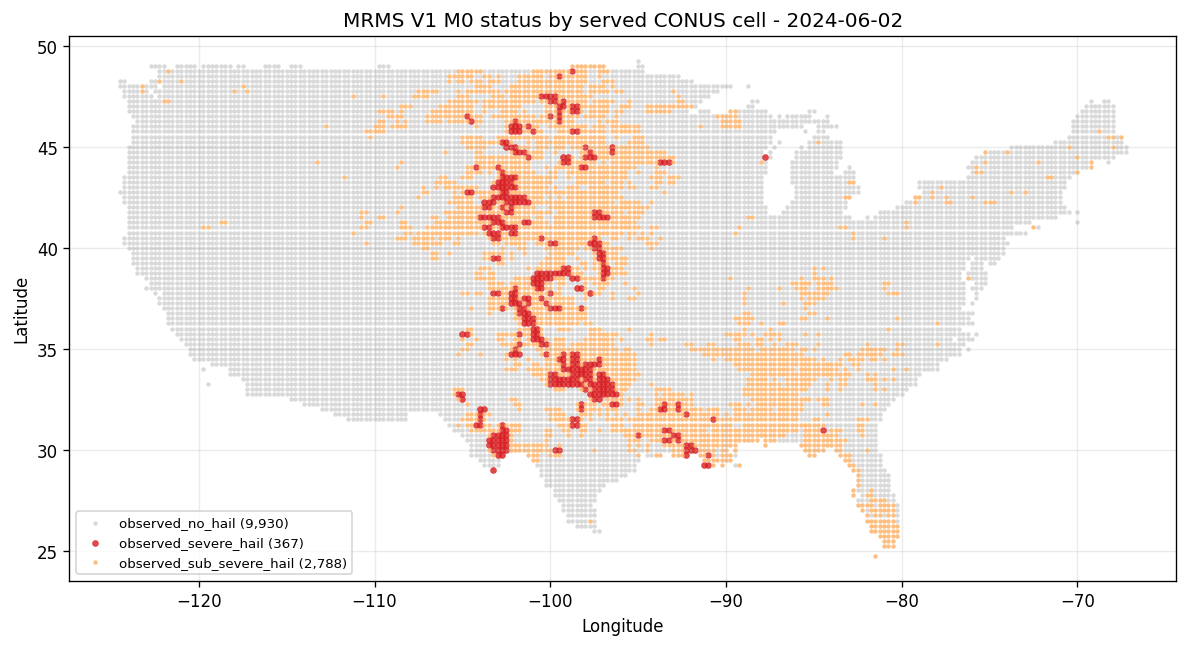

data/hazard_conus_grid/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607/qa/maps/mrms_v1_m0_status_map_20240603_20260616T172929Z.png


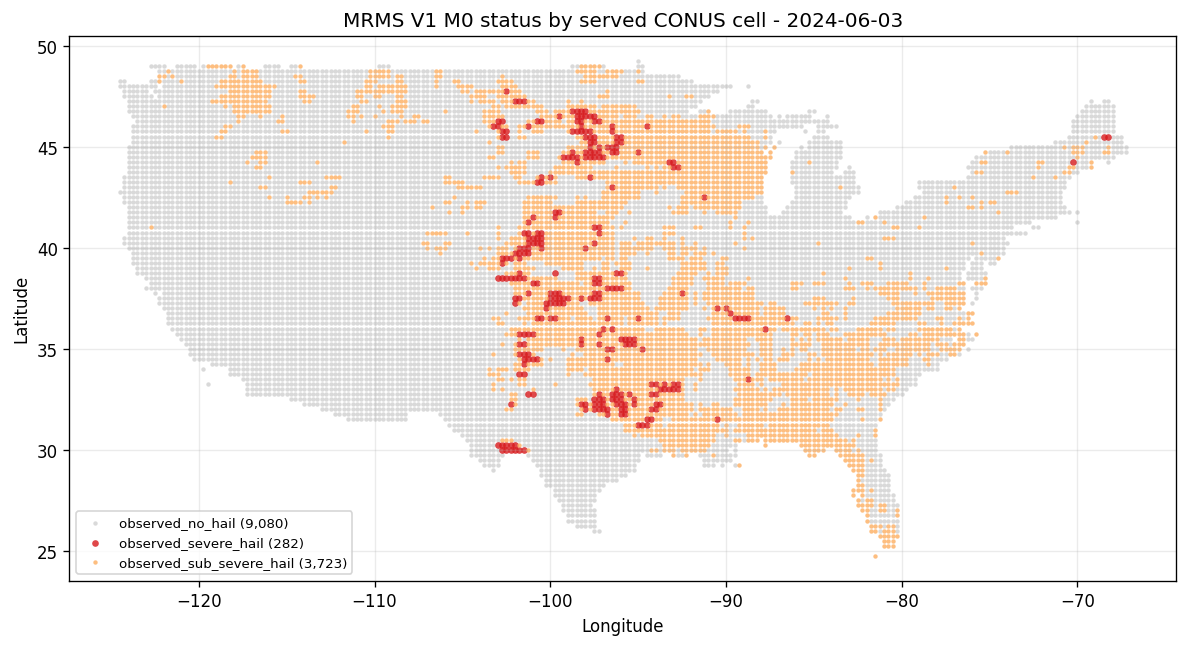

data/hazard_conus_grid/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607/qa/maps/mrms_v1_m0_status_map_20240604_20260616T172929Z.png


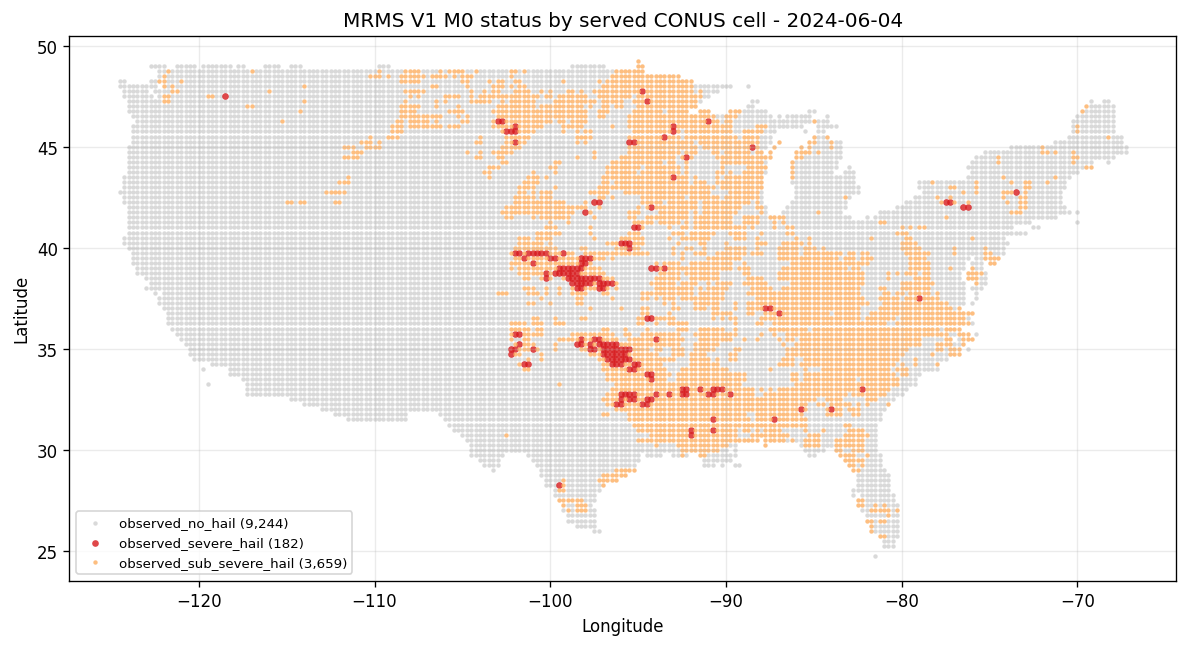

data/hazard_conus_grid/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607/qa/maps/mrms_v1_m0_status_map_20240605_20260616T172929Z.png


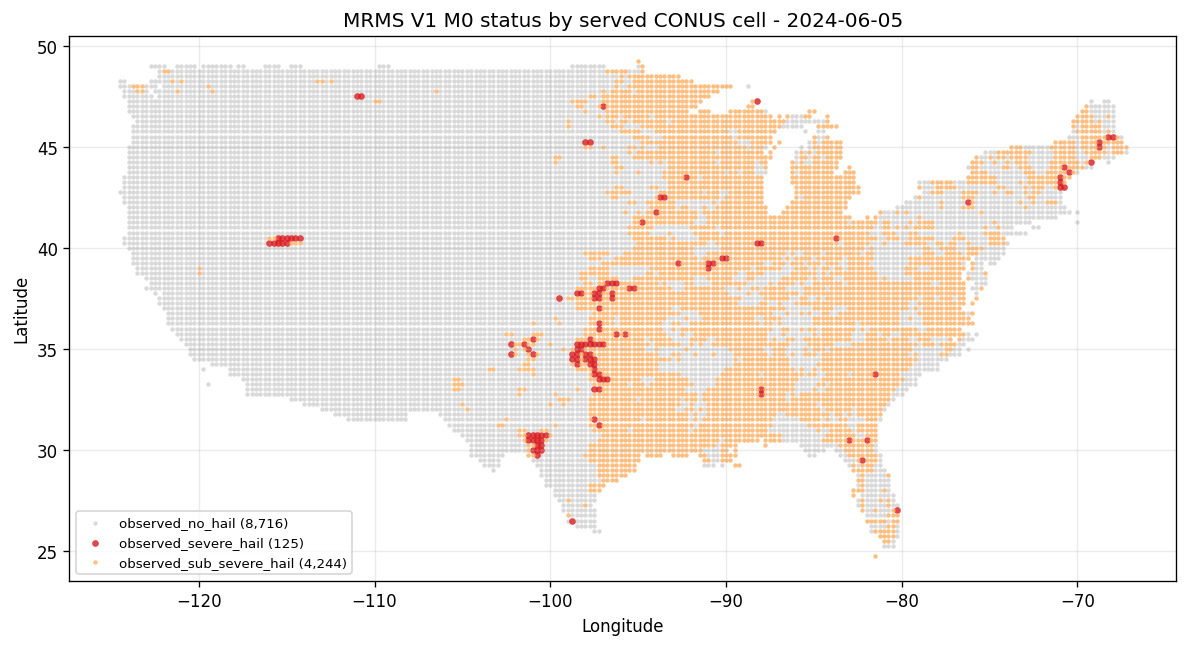

data/hazard_conus_grid/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607/qa/maps/mrms_v1_m0_status_map_20240606_20260616T172929Z.png


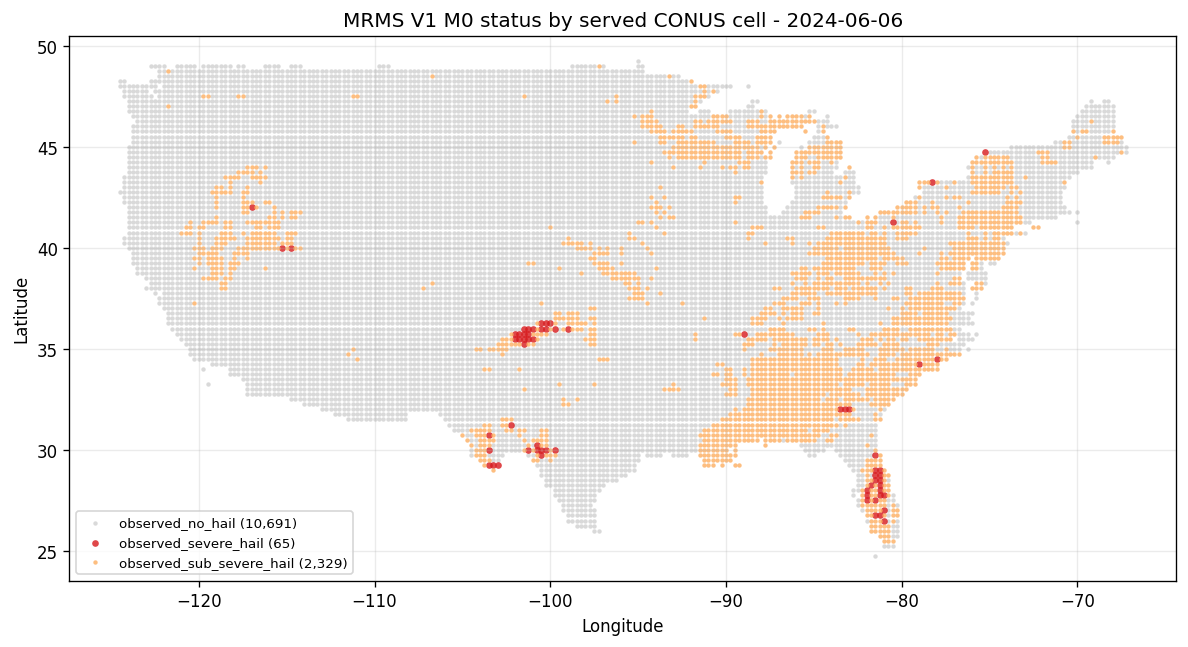

data/hazard_conus_grid/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607/qa/maps/mrms_v1_m0_status_map_20240607_20260616T172929Z.png


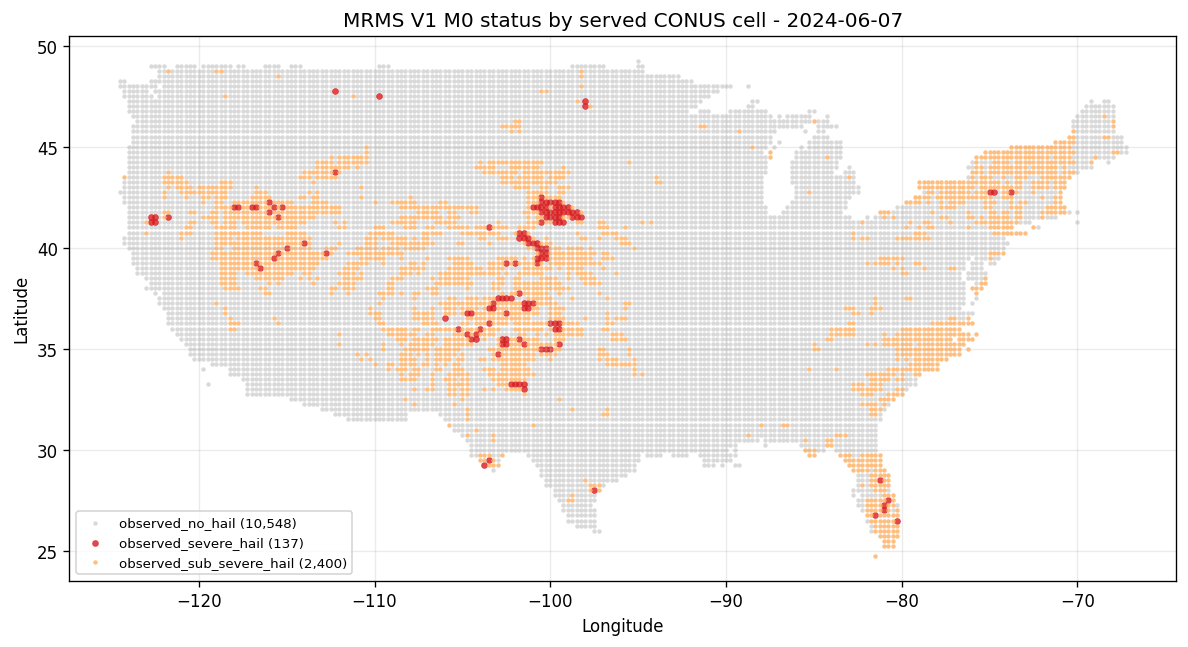

In [5]:
daily_status_summary = (
    batch_panel.groupby(["date", "coverage_status"])
    .agg(
        n_cells=("cell_id", "size"),
        n_positive_pixels=("n_native_pixels_positive", "sum"),
        n_severe_pixels=("n_native_pixels_severe", "sum"),
        max_mesh_mm=("mesh_max_mm", "max"),
    )
    .reset_index()
    .sort_values(["date", "coverage_status"])
)

top_cells = (
    batch_panel.sort_values(["n_native_pixels_severe", "mesh_max_mm"], ascending=False)
    .groupby("date", group_keys=False)
    .head(25)
    .sort_values(["date", "n_native_pixels_severe", "mesh_max_mm"], ascending=[True, False, False])
)

display(daily_status_summary)
display(
    top_cells[
        [
            "date",
            "cell_id",
            "state_abbr",
            "lat_center",
            "lon_center",
            "n_native_pixels_severe",
            "mesh_max_mm",
        ]
    ].head(50)
)

for path in map_paths:
    print(path.relative_to(ROOT))
    display(Image(filename=str(path)))

**Takeaway.** These maps are still daily QA views, not climatology. They are useful for seeing whether the
served-CONUS grid alignment, longitude convention, and status classes look plausible before scaling the
full 2,071-day denominator.

## 5 - Write batch artifacts

In [6]:
batch_panel.to_parquet(COMBINED_PANEL_PARQUET, index=False)
batch_manifest.to_csv(BATCH_MANIFEST_CSV, index=False)
daily_status_summary.to_csv(DAILY_STATUS_SUMMARY_CSV, index=False)
top_cells.to_csv(TOP_CELLS_CSV, index=False)

artifact_sizes = {
    "combined_panel_parquet_bytes": int(COMBINED_PANEL_PARQUET.stat().st_size),
    "batch_manifest_csv_bytes": int(BATCH_MANIFEST_CSV.stat().st_size),
    "daily_status_summary_csv_bytes": int(DAILY_STATUS_SUMMARY_CSV.stat().st_size),
    "top_cells_csv_bytes": int(TOP_CELLS_CSV.stat().st_size),
    "qa_map_total_bytes": int(sum(path.stat().st_size for path in map_paths)),
}

metadata = {
    "artifact_family": "mrms_v1_m0_daily_cell_evidence_batch",
    "status": "batch_proof",
    "hazard": "hail",
    "source_set": "MRMS_ONLY",
    "source_product": PRODUCT,
    "threshold_mm": THRESHOLD_MM,
    "run_id": RUN_ID,
    "batch_label": BATCH_LABEL,
    "batch_start_date": BATCH_START_DATE,
    "batch_end_date": BATCH_END_DATE,
    "source_inventory_run_id": SOURCE_INVENTORY_RUN_ID,
    "source_inventory_parquet": str(SOURCE_INVENTORY_PARQUET.relative_to(ROOT)),
    "n_dates": int(len(batch_inventory)),
    "n_served_cells": int(len(served)),
    "expected_rows": int(expected_rows),
    "n_output_rows": int(len(batch_panel)),
    "coverage_status_counts": batch_panel["coverage_status"].value_counts().to_dict(),
    "daily_manifest": manifest_rows,
    "local_run_dir": str(LOCAL_RUN_DIR.relative_to(ROOT)),
    "gcs_run_root": GCS_RUN_ROOT,
    "upload_to_gcs": UPLOAD_TO_GCS,
    "elapsed_seconds": round(time.perf_counter() - batch_start_time, 3),
    "artifact_sizes": artifact_sizes,
    "outputs": {
        "combined_panel_parquet": str(COMBINED_PANEL_PARQUET.relative_to(ROOT)),
        "batch_manifest_csv": str(BATCH_MANIFEST_CSV.relative_to(ROOT)),
        "daily_status_summary_csv": str(DAILY_STATUS_SUMMARY_CSV.relative_to(ROOT)),
        "top_cells_csv": str(TOP_CELLS_CSV.relative_to(ROOT)),
        "metadata_json": str(METADATA_JSON.relative_to(ROOT)),
        "daily_partitions_root": str(LOCAL_RUN_DIR.relative_to(ROOT)),
        "qa_maps": [str(path.relative_to(ROOT)) for path in map_paths],
    },
    "allowed_use": [
        "MRMS V1 full-grid M0 batch proof",
        "runtime/output-size measurement for runner decision",
        "input to M0 batch reconciliation design",
    ],
    "not_allowed_use": [
        "final full-record M0 evidence layer",
        "M1 frequency or size distribution",
        "reportable EAL/PML/VaR/TVaR input",
        "runner choice without reviewing runtime/output-size results",
    ],
    "caveats": [
        "Small accepted-date batch only.",
        "Raw MRMS MESH is radar-estimated and not de-biased.",
        "No NOAA/SPC validation is joined here.",
        "No MYRORSS evidence is used in V1.",
        "Native-pixel area is approximated by pixel count for this proof.",
    ],
}
METADATA_JSON.write_text(json.dumps(metadata, indent=2) + "\n")

print("wrote combined panel:", COMBINED_PANEL_PARQUET.relative_to(ROOT))
print("wrote batch manifest:", BATCH_MANIFEST_CSV.relative_to(ROOT))
print("wrote daily summary:", DAILY_STATUS_SUMMARY_CSV.relative_to(ROOT))
print("wrote top cells:", TOP_CELLS_CSV.relative_to(ROOT))
print("wrote metadata:", METADATA_JSON.relative_to(ROOT))
print("artifact sizes:", artifact_sizes)

wrote combined panel: data/hazard_conus_grid/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607/mrms_v1_m0_daily_cell_evidence_20240601_20240607_20260616T172929Z.parquet
wrote batch manifest: data/hazard_conus_grid/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607/mrms_v1_m0_batch_manifest_20240601_20240607_20260616T172929Z.csv
wrote daily summary: data/hazard_conus_grid/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607/mrms_v1_m0_daily_status_summary_20240601_20240607_20260616T172929Z.csv
wrote top cells: data/hazard_conus_grid/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607/mrms_v1_m0_top_cells_20240601_20240607_20260616T172929Z.csv
wrote metadata: data/hazard_conus_grid/hail/v1_mrms_only/m0_daily_cell_evidence/run_id=20260616T172929Z/batch=20240601_20240607/metadata_20240601_20240607_20260616T172929Z.json
artifact sizes: {'combi

## 6 - Optional GCS upload

Upload is disabled by default. When enabled, each file under this run-scoped local batch directory is copied
to the matching GCS run prefix. The destination must not already exist.

In [7]:
def gcs_prefix_exists(uri: str) -> bool:
    result = subprocess.run(
        ["gcloud", "storage", "ls", uri],
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        check=False,
    )
    return result.returncode == 0


def upload_tree(local_root: Path, gcs_root: str) -> list[str]:
    if gcs_prefix_exists(gcs_root):
        raise FileExistsError(f"GCS destination already exists: {gcs_root}")

    uploaded_uris: list[str] = []
    for path in sorted(p for p in local_root.rglob("*") if p.is_file()):
        rel = path.relative_to(local_root)
        destination = f"{gcs_root}/{rel.as_posix()}"
        subprocess.run(["gcloud", "storage", "cp", str(path), destination], check=True)
        uploaded_uris.append(destination)
    return uploaded_uris


if UPLOAD_TO_GCS:
    try:
        uploaded_gcs_outputs = upload_tree(LOCAL_RUN_DIR, GCS_RUN_ROOT)
        metadata["upload_status"] = "uploaded"
        metadata["uploaded_gcs_outputs"] = uploaded_gcs_outputs
        METADATA_JSON.write_text(json.dumps(metadata, indent=2) + "\n")
        subprocess.run(["gcloud", "storage", "cp", str(METADATA_JSON), f"{GCS_RUN_ROOT}/{METADATA_JSON.name}"], check=True)
        print("uploaded artifacts:")
        for uri in uploaded_gcs_outputs:
            print("-", uri)
    except Exception as exc:
        metadata["upload_status"] = "failed"
        metadata["upload_error"] = repr(exc)
        METADATA_JSON.write_text(json.dumps(metadata, indent=2) + "\n")
        print("GCS upload failed; local artifacts remain valid.")
        print("upload_error:", repr(exc))
else:
    metadata["upload_status"] = "skipped"
    METADATA_JSON.write_text(json.dumps(metadata, indent=2) + "\n")
    print("UPLOAD_TO_GCS is false; no remote artifacts written.")

UPLOAD_TO_GCS is false; no remote artifacts written.


## 7 - Recap and next step

In [8]:
recap = pd.DataFrame(
    [
        {
            "run_id": RUN_ID,
            "batch_label": BATCH_LABEL,
            "dates": len(batch_inventory),
            "served_cells": len(served),
            "output_rows": len(batch_panel),
            "expected_rows": expected_rows,
            "total_severe_cell_days": int((batch_panel["coverage_status"] == "observed_severe_hail").sum()),
            "total_sub_severe_cell_days": int(
                (batch_panel["coverage_status"] == "observed_sub_severe_hail").sum()
            ),
            "elapsed_seconds": metadata["elapsed_seconds"],
            "combined_panel_mb": round(artifact_sizes["combined_panel_parquet_bytes"] / 1_000_000, 3),
            "gcs_run_root": GCS_RUN_ROOT if UPLOAD_TO_GCS else "",
        }
    ]
)
display(recap)

,run_id,batch_label,dates,served_cells,output_rows,expected_rows,total_severe_cell_days,total_sub_severe_cell_days,elapsed_seconds,combined_panel_mb,gcs_run_root
0,20260616T172929Z,20240601_20240607,7,13085,91595,91595,1450,21134,7.535,0.512,


This batch proves the M0 evidence shape for multiple accepted MRMS days. Next:

```text
inspect runtime/output size/maps
  -> choose runner path for full 2,071-day denominator
  -> process independent M0 batches
  -> reconcile M0
  -> build M1
```